# The workbench

The live devising path, one call at a time, with everything it sends and everything it gets back on the page. Nothing here is a copy: the prompts are read out of `agents/` and `shared/`, and the calls are the ones `panel/devising.py` and `panel/continuing.py` make.

Where the product loops on its own — a repair, a check, the gate — there is a cell, so what it does silently in a container is visible here in order.

One afternoon is n=1. What to try is decided here; whether it worked is answered by `python -m research.run`.

In [1]:
import os
import secrets
import sys
import time
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import research.bench as bench  # noqa: E402
from agents.experience_deviser import ExperienceDeviser, experience_in, the_prompt  # noqa: E402
from orchestrator.router import FoundryConfig, FoundryRouter  # noqa: E402
from orchestrator.safety import (  # noqa: E402
    AzureContentSafetyGate,
    ContentSafetyConfig,
    screen_experience,
)
from shared.agents import AgentContext  # noqa: E402
from shared.ids import LearnerId  # noqa: E402
from shared.seal import Sealer, SealPurpose  # noqa: E402

bench.environment()

# Built exactly as `panel/devising.py` builds it, so the gate and the router here are the
# ones production uses. The safety key is per-process: the seal this gate mints travels
# nowhere, on this path or on that one.
ENVIRONMENT = dict(os.environ)
KEY = ENVIRONMENT.get("LANTERNINA_SAFETY_KEY", "").encode() or secrets.token_bytes(32)
GATE = AzureContentSafetyGate(
    ContentSafetyConfig.from_env(ENVIRONMENT),
    Sealer(SealPurpose.CONTENT_SAFETY, KEY, "orchestrator.safety"),
)
ROUTER = FoundryRouter(FoundryConfig.from_env(ENVIRONMENT), gate=GATE)
CTX = AgentContext(router=ROUTER, learner_id=LearnerId(""), learner_hints={}, now=time.time())
DEVISER = ExperienceDeviser()

print("prompt fingerprint:", bench.reload_prompts())

# Every call any router makes, with the prompt as it went and the answer as it came.
# Patched on the class and not on CTX's router: `panel/continuing.py` builds its own, and a
# call made inside an agent would otherwise leave no trace.
CALLS: list[dict[str, object]] = []


def _remember(name: str):
    original = getattr(FoundryRouter, name)

    async def instead(self, request):
        began = time.time()
        payload = await original(self, request)
        came = getattr(payload, "text", None)
        if came is None:
            came = f"<{len(getattr(payload, 'body', b''))} bytes of image>"
        CALLS.append(
            {
                "purpose": request.purpose or name,
                "seconds": round(time.time() - began, 1),
                "sent": request.prompt,
                "came": came,
            }
        )
        print(
            f"[{len(CALLS)}] {request.purpose} · {CALLS[-1]['seconds']} s · "
            f"{len(request.prompt)} characters sent, {len(came)} back"
        )
        return payload

    setattr(FoundryRouter, name, instead)


if not getattr(FoundryRouter, "_remembered", False):
    for _name in ("analyze", "generate_for_user"):
        _remember(_name)
    FoundryRouter._remembered = True

BAR = "=" * 78


def said(n: int = -1) -> None:
    """One call whole: what went up and what came back."""
    one = CALLS[n]
    print(f"{BAR}\n[{n if n >= 0 else len(CALLS) - 1}] {one['purpose']} · {one['seconds']} s")
    print(f"{BAR}\nWHAT WAS SENT — {len(one['sent'])} characters\n{BAR}")
    print(one["sent"])
    print(f"{BAR}\nWHAT CAME BACK — {len(one['came'])} characters\n{BAR}")
    print(one["came"])


def conversation(to: Path | None = None) -> Path:
    """Every call so far, in order, whole, written where it can be read and searched."""
    to = to or ROOT / "tmp" / "conversation.txt"
    to.parent.mkdir(exist_ok=True)
    parts = []
    for n, one in enumerate(CALLS):
        parts.append(f"{BAR}\n[{n}] {one['purpose']} · {one['seconds']} s\n{BAR}")
        parts.append(f"--- SENT ({len(one['sent'])} characters) ---\n{one['sent']}")
        parts.append(f"--- CAME BACK ({len(one['came'])} characters) ---\n{one['came']}\n")
    to.write_text("\n".join(parts), encoding="utf-8", newline="")
    for n, one in enumerate(CALLS):
        print(f"[{n}] {one['purpose']:44} {one['seconds']:6} s  "
              f"{len(one['sent']):7} sent  {len(one['came']):7} back")
    print(f"\n{len(CALLS)} calls · {to}")
    return to


prompt fingerprint: bdbfb5b564f4


## The calls, in order

Six, and every one of them is the call the container makes. `panel/devising.py` runs 1 to 4 inside one request and returns; the house walks the moments, and 5 happens at every `hand_over`; `panel/continuing.py` runs 6 when a page comes back off the glass and an outcome says `ask`.

1. **which method** — to the model that writes. Sends `choosing` and a sample of sixty method names, no records. Comes back two ids and a reason. A few seconds.
2. **the afternoon** — to the model that writes. Sends the whole standing instruction and this household's material, about 34 000 characters. Comes back one JSON document: title, overview, themes, script, minutes, drawn, moments. 76–184 s, median about 140.
3. **a repair, and only if something refused it** — to the model that writes. Sends `repair`, what was refused, and the document as it was; comes back the same JSON again. Once and no more. It is `repair_unreadable` when the format would not read the answer at all, and `repair` when one of the seven checks refused it.
4. **the gate** — to the safety gate. Sends the document's own words, comes back through or `SafetyBlocked`. Seconds.
5. **the page, at every `hand_over`** — to the model that draws. Sends `page_maker.*`, built from the page's own words. Comes back one PNG. 25–35 s a page.
6. **the continuation, when an outcome says `ask`** — to the model that writes. Sends `experience_continuer.*`, the afternoon so far and what came back on the sheet. Comes back the rest of the moments. 15–25 s.

A role and not a deployment: which model answers each one is the router's business, and `research/env.ps1` says which is deployed today.

**Everything sent and everything returned is kept.** The setup cell records every call on `FoundryRouter` itself, so a call made inside an agent cannot escape it. `said()` prints the last one whole, `said(2)` the third, and `conversation()` writes all of them in order to `tmp/conversation.txt`, which is the file to read when looking for the place a prompt goes wrong.

The stand-in is the one call in this notebook the house never makes: it is `research/calls.adolescent.md`, and it exists so an afternoon can be walked with nobody in the room.

**Four things this notebook does differently, and none of them changes what is sent.** A failed choosing call raises here and is drawn around in the container. A document the checks still refuse after its one repair raises `RefusedByTheChecks` in the container and is only printed here. The gate is not closed at the end. And the walk — the stand-in, and stepping through the moments — is `research/`, not the product: in a house a person does that.

Credentials are not in `env.ps1`: the router builds a `DefaultAzureCredential`, which finds the `az` session in the `AZURE_CONFIG_DIR` named there. If a call fails on authentication, run `az account get-access-token` in a terminal with that variable set — `az account show` reads the cache and succeeds even on an expired token.

## 1. The prompts, as they are

Every block, with the format's own numbers filled in. The placeholders left as `$name` are the ones that carry a household's material, and the cell after next is where they are filled.

In [2]:
P = bench.everything()

for key, text in P.items():
    print(f"{key:26} {len(text):6}")
print(f"{'':26} {sum(len(one) for one in P.values()):6}  in all")

task                         2077
format                       4935
shape-of-a-moment            2765
acts                         1099
marks-on-a-page              3466
ten-dimensions               1135
rules-head                     88
limits                        482
rules-tail                    713
asking                        376
manner-head                   391
how-the-text-reads            860
what-to-refuse                421
only-what-you-can-answer     1399
worth-doing                  5117
manner-tail                   114
method                        810
household                    1391
pitch                         516
stand-in                     1535
                            29690  in all


In [3]:
print(P["task"])

You are making one afternoon for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this afternoon actually is. Nothing here is set in stone either — an afternoon can turn out differently once it has started, and that is ordinary rather than a failure.

An afternoon is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuinely not known, and

## 2. The household

Everything that decides one afternoon, as one dictionary. `research/run.py` sends the same one to `devise_experience`.

In [4]:
from research.households import Household, Memory, arguments

HOUSE = Household(
    name="bench",
    interests=("i treni", "le mappe vecchie"),
    avoid=("i ragni",),
    load="middle",
    ink="middle",
    span="middle",
    sheets=2,
    note="",
)
MEMORY = Memory()  # no history: the first afternoon of this house
ARGS = arguments(HOUSE, MEMORY)

for name, value in ARGS.items():
    shown = value if isinstance(value, str) else repr(value)
    print(f"{name:12} {shown[:110] or '—'}")

capabilities frozenset({<HouseCapability.SHOW_800X480_1BIT: 'show_800x480_1bit'>, <HouseCapability.PRINT_A4: 'print_a4'>, <
language     Italian
interests    ('i treni', 'le mappe vecchie')
avoid        ('i ragni',)
pitch        two things that have to be put side by side before either makes sense, and one turn where what looked true sto
sheets       2
note         —
already      ()
recent       ()
happened     —
counts       {"afternoonsRun": 0, "ranToTheEnd": 0, "endedEarly": 0, "stopped": 0, "sheetsWrittenOn": 0, "sheetsBlank": 0}
direction    Ask for about what the last ones asked for. Nothing here says to move either way.
ground       —


## 3. Call one: which method

A cheap call before the expensive one. It carries a sample of sixty names out of `methods/` and no records, so the corpus stays outside the prompt. The sample is there because the whole catalogue made the model pick the same pair twice out of twice: the same judgement on the same list gives the same answer, which was worse than drawing.

In [5]:
from shared.methods import CATALOGUE, by_id, draw, index, load, runnable

RUNNABLE = runnable(load(), capabilities=ARGS["capabilities"])
CATALOGUE_SENT = index(RUNNABLE, sample=CATALOGUE)
print(f"{len(RUNNABLE)} methods this house can run · {len(CATALOGUE_SENT)} characters of names\n")
print(CATALOGUE_SENT[:1200])

145 methods this house can run · 5031 characters of names

name-whoever-made-it: print who made it and when (a move)
three-sheets-that-never-say-they-are-one: three sheets on three days that never say they are one
a-box-ticked-in-the-moment: a box in the margin, ticked the moment you stop (a move)
line-that-does-not-hold: point at the line that does not hold and repair it
which-one-nearly-went-the-other-way: ask which one nearly went the other way (a move)
seven-things-in-the-wrong-room: find seven things that are in the wrong room
the-chain-that-comes-back-to-your-own-number: a chain of steps ending on a number only you know
hand-over-the-wrong-version-to-be-corrected: give them a wrong version and ask for corrections (a move)
sums-that-fix-their-own-digits: fill a grid with digits the sums leave no choice about
the-column-for-what-is-missing: three columns: known, missing, where to look
slip-of-labelled-lines: print a slip with one labelled line per thing
not-finished-until-it-is-in-

In [6]:
began = time.time()
WANTS_FORM, WANTS_MOVE, WHY = await DEVISER.choose(
    CTX,
    catalogue=CATALOGUE_SENT,
    interests=ARGS["interests"],
    avoid=ARGS["avoid"],
    already=ARGS["already"],
    pitch=ARGS["pitch"],
)
ASKED_FOR = by_id(RUNNABLE, [WANTS_FORM, WANTS_MOVE])
FORM = next((one for one in ASKED_FOR if not one.is_a_move), None)
MOVE = next((one for one in ASKED_FOR if one.is_a_move), None)
if FORM is None or MOVE is None:
    # What `panel/devising.py` does: a step that exists to improve an afternoon may never
    # be the step that costs one.
    FORM, MOVE = draw(RUNNABLE)
    print("the choice did not resolve; drew instead")
print(f"{time.time() - began:.1f} s · {FORM.method_id} + {MOVE.method_id}\n{WHY}")

[1] choosing what to build an afternoon out of · 14.3 s · 6454 characters sent, 206 back
14.3 s · what-changed-between-two-pictures + one-fact-that-changes-what-was-already-read
Two old railway maps invite side-by-side comparison before one new fact overturns the first reading.


In [7]:
said()

[0] choosing what to build an afternoon out of · 14.3 s
WHAT WAS SENT — 6454 characters
You are about to devise one afternoon for one adolescent to spend at home. First you are choosing what to build it out of.

Below is a catalogue of methods that work on paper, filtered to the ones this house can actually run. Each line is an id and a name. Some are marked as a move: a move is not something to do on its own — it is applied to a form and changes what the form asks of somebody.

The parent wrote down these interests, as a place to begin: ["i treni", "le mappe vecchie"]
And these things to keep away from: ["i ragni"]
Afternoons already offered here: []
How the afternoon should be pitched: two things that have to be put side by side before either makes sense, and one turn where what looked true stops being true
a sheet may ask for a few words as well as marks, and the space left for them should be small enough that filling it is obviously finishable
write the standard weight at the middl

## 4. The whole prompt, before paying for it

In [8]:
PROMPT = the_prompt(**ARGS, form=FORM, move=MOVE)
print(f"{len(PROMPT)} characters\n")
print(PROMPT)

34016 characters

You are making one afternoon for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this afternoon actually is. Nothing here is set in stone either — an afternoon can turn out differently once it has started, and that is ordinary rather than a failure.

An afternoon is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuin

## 5. Call two: the afternoon

One answer, whole. Measured at 76–184 s, median about 140.

In [9]:
began = time.time()
ANSWER = await DEVISER.ask(CTX, **ARGS, form=FORM, move=MOVE)
print(f"{time.time() - began:.1f} s · {len(ANSWER)} characters back")
print(ROUTER.last_usage)

[2] devising an afternoon · 133.9 s · 34016 characters sent, 13873 back
133.9 s · 13873 characters back
ModelUsage(deployment='gpt-5.6-sol-2026-07-09', request_id='d6a91094-14bf-4afd-a9a1-c7a3aed19da8', input_tokens=7803, output_tokens=11974, cached_input_tokens=0, reasoning_tokens=8036, size='', quality='')


In [10]:
said()

[1] devising an afternoon · 133.9 s
WHAT WAS SENT — 34016 characters
You are making one afternoon for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this afternoon actually is. Nothing here is set in stone either — an afternoon can turn out differently once it has started, and that is ordinary rather than a failure.

An afternoon is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult 

## 6. The format reads it

In [11]:
from shared.experience import ExperienceError

REFUSAL = ""
try:
    EXPERIENCE = experience_in(ANSWER)
except ExperienceError as exc:
    EXPERIENCE, REFUSAL = None, str(exc)
    print("the format would not read it:", REFUSAL)
else:
    print(f"{EXPERIENCE.title} · {len(EXPERIENCE.moments)} moments · {EXPERIENCE.minutes} min")

La prova che Ada voleva far respingere · 6 moments · 78 min


If it would not read it at all, the answer goes back up with the refusal. `repair_unreadable`.

In [12]:
if REFUSAL:
    began = time.time()
    EXPERIENCE = await DEVISER.repair_unreadable(
        CTX, answer=ANSWER, refusal=REFUSAL, language=ARGS["language"]
    )
    print(f"{time.time() - began:.1f} s · {EXPERIENCE.title}")
else:
    print("the format read it; nothing to repair")

the format read it; nothing to repair


## 7. The seven checks

`shared/experience_checks.py`. They read the shape of the document and not its sense, and a complaint that comes back every afternoon names the rule in the prompt to work on.

In [13]:
from shared.experience_checks import check

COMPLAINTS = check(EXPERIENCE, recent=ARGS["recent"], sheets_at_most=ARGS["sheets"])
print("; ".join(map(str, COMPLAINTS)) or "no complaints")

no complaints


One repair and no more, which is what `panel/devising.py` allows.

In [14]:
if COMPLAINTS:
    began = time.time()
    EXPERIENCE = await DEVISER.repair(
        CTX, refused=EXPERIENCE, complaints=COMPLAINTS, language=ARGS["language"]
    )
    COMPLAINTS = check(EXPERIENCE, recent=ARGS["recent"], sheets_at_most=ARGS["sheets"])
    print(f"{time.time() - began:.1f} s · after the repair: ")
    print("; ".join(map(str, COMPLAINTS)) or "no complaints")
else:
    print("nothing to repair")

nothing to repair


## 8. The gate

The chokepoint. Nothing on this path returns past it: the parse and the checks can refuse, but only screening lets something through.

In [15]:
began = time.time()
await screen_experience(GATE, EXPERIENCE, context="devising an afternoon")
DOCUMENT = EXPERIENCE.to_dict()
print(f"{time.time() - began:.1f} s · the gate let it through")

1.6 s · the gate let it through


## 9. What came out

Only what would reach somebody in the room.

In [16]:
from tools.as_it_arrives import read

COUNTED = read(DOCUMENT)

──────────────────────────────────────────────────────────────────────────────
  La prova che Ada voleva far respingere
  Confronta due prove di una vecchia mappa ferroviaria, cerchia sette cambi, li classifica e scopre perché Ada consegnò quella sbagliata. La stampante produce una pagina del suo taccuino e un avviso ferroviario. Alla fine restano una ricostruzione annotata e l’avviso piegato. Non serve altro. Può non piacere: per un tratto si confrontano settanta segni molto simili.
  78 minuti
──────────────────────────────────────────────────────────────────────────────

1. [hand_over] Una pagina nel vassoio
    L’archivio ha liberato una pagina.
    Ada controllò entrambe le prove.
    Consegnò quella a destra.
    Apri la pagina di Ada sul tavolo.

    ┌─ Le due prove di Ada
    │  (disegno: Two side-by-side arrays, each five rows of fourteen evenly spaced cells. Left rows: ●▲│×● empty │×●▲│×●▲; ▲│×●▲│×● empty │×●▲│; │×●▲│×●▲│×●▲│×; ×●▲│×●▲│×●▲│×●; ●×│▲●× empty ▲●×│▲●×. Right arra

And the script, which is what the parent approves and what whoever runs the afternoon reads.

In [17]:
print(EXPERIENCE.script)

THE WORLD L’Archivio del Binario Zero occupa una stanza dietro una stazione dismessa. La luce delle finestre si ferma davanti ai cassetti; dentro odora di ferro tiepido e finocchio secco. Nessuno nomina il binario zero, anche se ogni mappa respinta lascia lì il proprio percorso. THE WAY IN Nel vassoio della stampante c’è oggi una pagina non richiesta. Viene dal taccuino di Ada, la disegnatrice delle linee. Qualcuno prende la pagina di Ada e la posa sul tavolo: mostra due prove quasi uguali, e dice che Ada le controllò entrambe prima di consegnare quella a destra. THE QUESTION Che cosa voleva ottenere Ada consegnando la prova a destra? Risposta: Ada voleva che la prova fosse respinta, così il treno sarebbe rimasto sul percorso precedente. Cosa lo stabilisce: i sette cambi si dividono in tre comparse, due perdite e due scambi. Cosa lo stabilisce: la prova destra contiene quindi un segno in più. Cosa lo stabilisce: l’avviso dice che una prova con un totale diverso viene respinta e lascia 

## 10. The walk

Run the four cells below in order, then run them again, until it is over. Each pass is one moment.

⚠️ The image deployment has capacity 2 in this region, so two page calls within about 30 s answer 429. A page is 25–35 s and a few cents. Which one is deployed today is in `research/env.ps1`, and the cell above prints what the last call cost.

In [18]:
from IPython.display import Image, display

from agents.page_maker import PageMaker
from shared.experience import ASK, Collect, HandOver, Say, Weight

WEIGHT = Weight.STANDARD
MOOD = "una giornata normale, c'è voglia di fare qualcosa"

BY_ID = {one.id: one for one in EXPERIENCE.moments}
ORDER = [one.id for one in EXPERIENCE.moments]
AT = ORDER[0]
MINUTES = 0
DISPLAYS: list[str] = []
SHEET = ""
CAME = None


def show(moment) -> None:
    """What this moment puts in the room, and the ladder somebody stuck would meet."""
    global MINUTES, SHEET
    weighing = moment.at(WEIGHT)
    MINUTES += weighing.minutes
    print(f"[{moment.act}] {moment.heading}   ({weighing.minutes} min, {MINUTES} in)")
    for line in weighing.lines:
        print(f"   display: {line}")
        DISPLAYS.append(line)
    for rung in moment.help:
        print(f"     after {rung.after_minutes} min: {' '.join(rung.lines)}")
    if isinstance(moment, HandOver):
        page = moment.page
        SHEET = "\n".join(
            [f"[{page.kind}] {page.title}", *page.note]
            + [f"- {one.label} ({one.room})" for one in page.spaces]
        )
        print(f"\n   page [{page.kind}] {page.title}")
        for line in page.note:
            print(f"     {line}")
        for space in page.spaces:
            print(f"     [ {space.label} — {space.room} ]")
        print(f"     drawing: {page.illustration}")
    if isinstance(moment, Collect):
        print(f"   way out: {moment.way_out.heading} ({moment.way_out.in_hand})")
        for one in moment.outcomes:
            print(f"   if {one.when} -> {one.then}")


def next_id(moment, came: str | None = None) -> str | None:
    """Where the afternoon goes after this. None is an ending, ASK is a continuation."""
    if isinstance(moment, (Say, HandOver)):
        i = ORDER.index(moment.id)
        return ORDER[i + 1] if i + 1 < len(ORDER) else None
    if isinstance(moment, Collect):
        return next((one.then for one in moment.outcomes if str(one.when) == came), ASK)
    return None

**a.** Where we are.

In [19]:
M = BY_ID[AT]
show(M)

[hand_over] Una pagina nel vassoio   (6 min, 6 in)
   display: L’archivio ha liberato una pagina.
   display: Ada controllò entrambe le prove.
   display: Consegnò quella a destra.
   display: Apri la pagina di Ada sul tavolo.
     after 2 min: Le prove differiscono in pochi punti. Un vuoto può essere un cambiamento.
     after 5 min: Confronta una riga alla volta. Conta ogni posto da sinistra.
     after 9 min: Cerca sette posti diversi. Sono comparse, perdite o scambi.
     after 14 min: Comparse: r1 p6, r2 p9, r5 p7. Perdite: r3 p4 e r4 p11. Scambi: r2 p2 e r5 p14. Questi sono i sette cambi.

   page [notebook] Le due prove di Ada
     Dal taccuino dell’Archivio del Binario Zero.
     Ada controllò le prove e consegnò quella a destra.
     La matita cerchia i sette punti diversi nelle prove.
     Il riquadro conserva ordine e tipo di ogni cambiamento.
     [ Ordine e tipo dei sette cambi — some_lines ]
     [ Prima lettura: correzione ordinaria — a_line ]
     [ Decisione ricostruit

**b.** The page, if this moment hands one over.

[3] drawing a notebook · 40.3 s · 3257 characters sent, 24 back
40.5 s · 121913 bytes


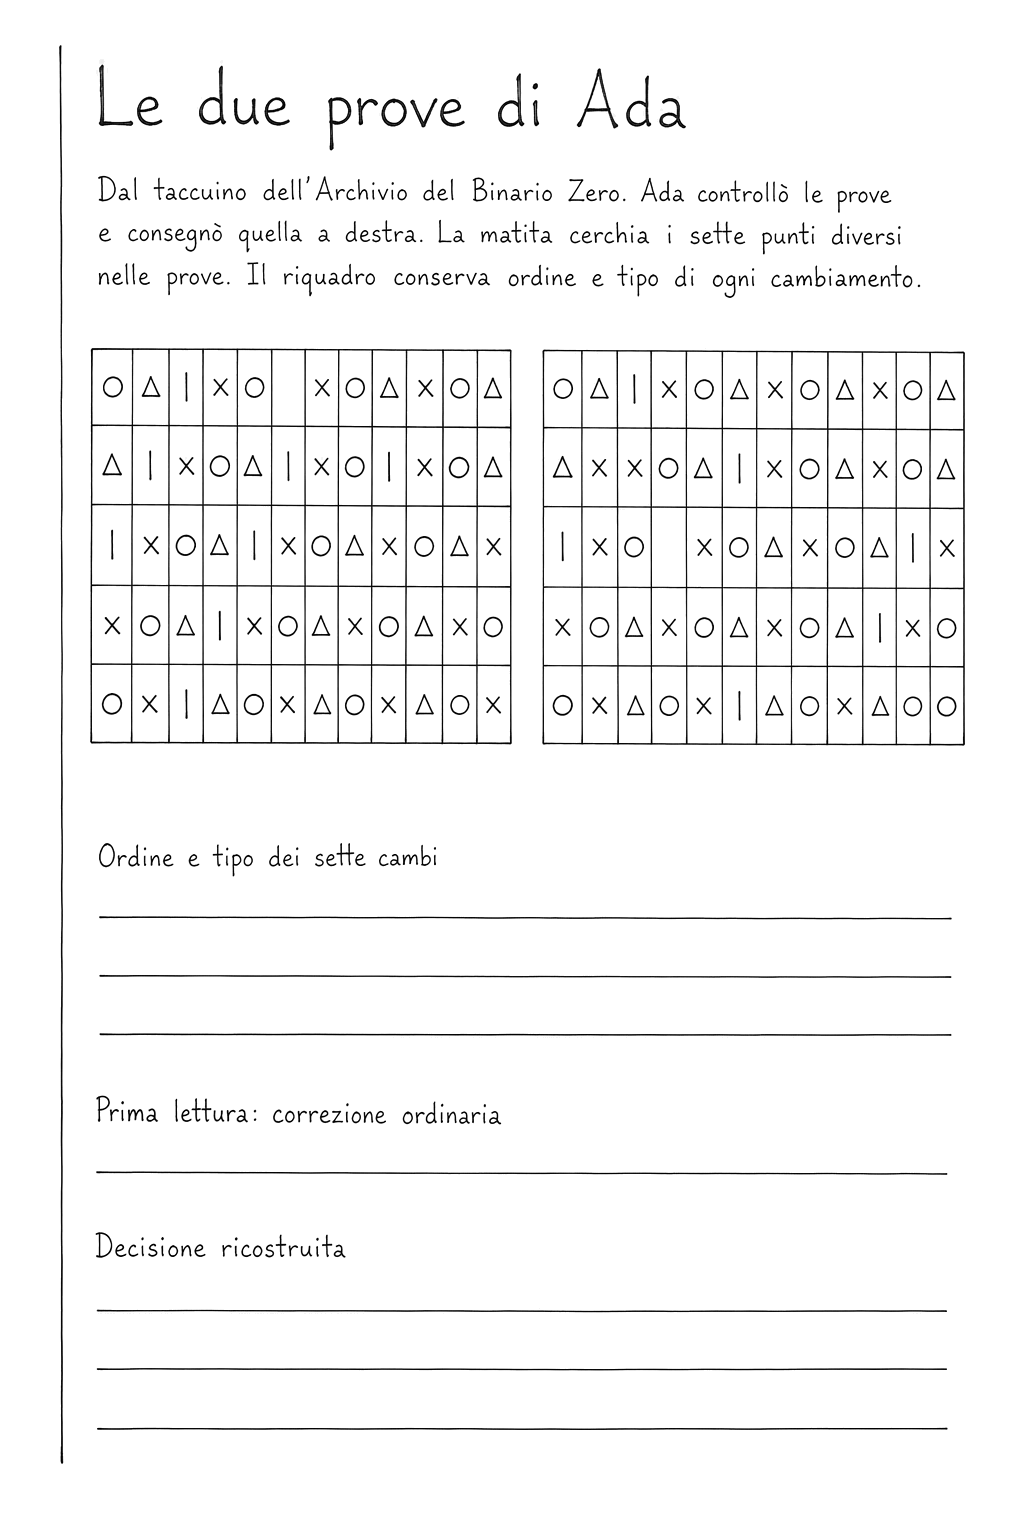

The page is a leaf out of a field notebook: a margin rule down the left and a quick sketch in one corner. Rule lines only where the page asks for something to be written, and leave the paper plain everywhere else.

Letter this large, as the title: "Le due prove di Ada"
Letter this smaller, under the title: "Dal taccuino dell’Archivio del Binario Zero. Ada controllò le prove e consegnò quella a destra. La matita cerchia i sette punti diversi nelle prove. Il riquadro conserva ordine e tipo di ogni cambiamento."
Leave three ruled lines, with "Ordine e tipo dei sette cambi" lettered above it
Leave one ruled line, long enough for a few words, with "Prima lettura: correzione ordinaria" lettered above it
Leave three ruled lines, with "Decisione ricostruita" lettered above it

What the drawing on the page shows: Two side-by-side arrays, each five rows of fourteen evenly spaced cells. Left rows: ●▲│×● empty │×●▲│×●▲; ▲│×●▲│×● empty │×●▲│; │×●▲│×●▲│×●▲│×; ×●▲│×●▲│×●▲│×●; ●×│▲●× empty ▲●×│▲●×. Ri

In [20]:
if isinstance(M, HandOver):
    began = time.time()
    PNG, ASKED = await PageMaker().draw(CTX, M.page)
    (ROOT / "tmp").mkdir(exist_ok=True)
    (ROOT / "tmp" / f"{M.id}.png").write_bytes(PNG)
    print(f"{time.time() - began:.1f} s · {len(PNG)} bytes")
    display(Image(PNG, width=520))
    print(ASKED)
else:
    print(f"{M.act} — nothing to draw here")

**c.** What the person did with it, if this moment collects one.

In [21]:
from string import Template

from research.calls import what_they_did

if isinstance(M, Collect):
    print(Template(P["stand-in"]).substitute(
        displays="\n".join(DISPLAYS), sheet=SHEET, mood=MOOD, minutes=MINUTES
    ))
    DID = await what_they_did(
        CTX, displays=DISPLAYS, sheet=SHEET, mood=MOOD, minutes_in=MINUTES
    )
    CAME = "marks" if str(DID.get("came")) == "marks" else "blank"
    print(f"\n{CAME} · {DID.get('onIt')} · stop: {DID.get('stop')}\n{DID.get('why')}")
else:
    CAME = None
    print(f"{M.act} — nobody is being asked for anything here")

hand_over — nobody is being asked for anything here


**d.** Take the branch, and go back to **a**.

In [22]:
AT = next_id(M, CAME)
if AT is None:
    print("over")
elif AT == ASK:
    print("the outcome says ask: the rest is bought from the continuer, in the cell below")
else:
    print(f"next: {AT}  ({BY_ID[AT].act})")

next: seven-changes  (say)


**e.** And if the branch said `ask`, buy the rest. This is `panel/continuing.py`, the second prompt, with its own gate and its own checks and no repair.

In [23]:
from panel.continuing import continue_experience

if AT == ASK:
    began = time.time()
    CARRYING_ON, SPENT = await continue_experience(
        experience=DOCUMENT,
        after=M.id,
        came=CAME,
        reading={"came": CAME, "reading": str(DID.get("onIt", ""))},
        now=time.time(),
        pitch=ARGS["pitch"],
    )
    print(f"{time.time() - began:.1f} s · {len(CARRYING_ON.moments)} more moments\n")
    for one in CARRYING_ON.moments:
        print(f"{one.id:26} {one.act:10} {one.heading}")
    # Carry on walking into what was just bought.
    BY_ID |= {one.id: one for one in CARRYING_ON.moments}
    ORDER += [one.id for one in CARRYING_ON.moments]
    AT = CARRYING_ON.moments[0].id
else:
    print("no continuation was asked for")

no continuation was asked for


## 11. Changing a block

The blocks are the files in `agents/` and `shared/`. Edit one in the editor, run `bench.reload_prompts()`, and go back to section 4: the fingerprint changes only when the text being sent changed.

When one is settled: `python -m tools.prompts --write`, then `python -m pytest -q`, then `python -m research.run --iterations 4 --seed 0 --label <name>` — six households, four iterations, about an hour, and the eight axes are the answer to whether it improved.

⚠️ Do not run `pytest` and a run at the same time: `tests/test_trail.py` fails with `Event loop is closed` on contention, and it looks like a real regression.

In [24]:
print("fingerprint:", bench.reload_prompts())

fingerprint: bdbfb5b564f4


## 12. The whole conversation

Every prompt and every answer, in order, in one file. That is what to read when an afternoon
comes out wrong: the place a prompt goes wrong is usually visible as the thing the answer did
that nobody asked for.

In [25]:
conversation()

[0] choosing what to build an afternoon out of     14.3 s     6454 sent      206 back
[1] devising an afternoon                         133.9 s    34016 sent    13873 back
[2] drawing a notebook                             40.3 s     3257 sent       24 back

3 calls · C:\code\lanternina\tmp\conversation.txt


WindowsPath('C:/code/lanternina/tmp/conversation.txt')